In [19]:
pip install tensorflow==2.13.1

In [20]:
import tarfile
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
import matplotlib.pyplot as plt

##Загружаю данные

In [21]:
dataset_url = "/content/flower_photos.tar"
dataset_dir = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
dataset_dir = pathlib.Path(dataset_dir).with_suffix('')

ValueError: unknown url type: '/content/flower_photos.tar'

In [22]:


# Путь к архиву
dataset_path = "/content/flower_photos.tar"

# Распаковка архива
tar = tarfile.open(dataset_path)
tar.extractall(path="/content/")
tar.close()

# Указание пути к распакованной директории
dataset_dir = pathlib.Path("/content/flower_photos")

Провека колличества изображений

In [23]:
image_count = len(list(dataset_dir.glob("*/*.jpg")))
print(f"Всего изображений: {image_count}")

Всего изображений: 3670


## Создание датасета

In [24]:
batch_size = 32
img_width = 180
img_height = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
	dataset_dir,
	validation_split=0.2,
	subset="training",
	seed=123,
	image_size=(img_height, img_width),
	batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
	dataset_dir,
	validation_split=0.2,
	subset="validation",
	seed=123,
	image_size=(img_height, img_width),
	batch_size=batch_size)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# cache
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Создаем модель, компилируем её и выводим summary

In [25]:
num_classes = len(class_names)
model = Sequential([
	layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

	layers.Conv2D(16, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Conv2D(32, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Conv2D(64, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Flatten(),
	layers.Dense(128, activation='relu'),
	layers.Dense(num_classes)
])


model.compile(
	optimizer='adam',
	loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
	metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 90, 90, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 45, 45, 64)        1

##Обучаю модель и вывожу график точности

Epoch 1/10
92/92 [==============================] - 92s 949ms/step - loss: 1.3473 - accuracy: 0.4298 - val_loss: 1.1206 - val_accuracy: 0.5450
Epoch 2/10
92/92 [==============================] - 82s 890ms/step - loss: 1.0116 - accuracy: 0.6069 - val_loss: 1.0369 - val_accuracy: 0.5817
Epoch 3/10
92/92 [==============================] - 83s 905ms/step - loss: 0.7904 - accuracy: 0.7098 - val_loss: 0.9975 - val_accuracy: 0.6226
Epoch 4/10
92/92 [==============================] - 80s 871ms/step - loss: 0.5991 - accuracy: 0.7786 - val_loss: 0.9188 - val_accuracy: 0.6580
Epoch 5/10
92/92 [==============================] - 81s 877ms/step - loss: 0.3754 - accuracy: 0.8730 - val_loss: 1.0929 - val_accuracy: 0.6240
Epoch 6/10
92/92 [==============================] - 82s 888ms/step - loss: 0.2225 - accuracy: 0.9244 - val_loss: 1.1810 - val_accuracy: 0.6158
Epoch 7/10
92/92 [==============================] - 82s 888ms/step - loss: 0.1124 - accuracy: 0.9619 - val_loss: 1.4118 - val_accuracy: 0.6567

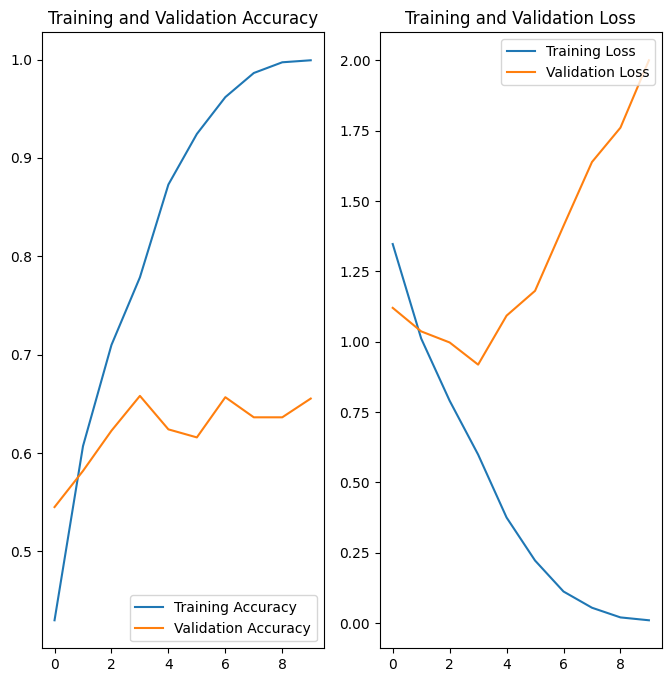

In [26]:
epochs = 10 # количество эпох
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=epochs)

# Визуализация
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

##Решение проблемы переобучения с помощью аргументации и регуляризации

In [27]:
model = Sequential([

	layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

	# аугментация
	layers.experimental.preprocessing.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
	layers.experimental.preprocessing.RandomRotation(0.1),
	layers.experimental.preprocessing.RandomZoom(0.1),
	layers.experimental.preprocessing.RandomContrast(0.2),


	layers.Conv2D(16, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Conv2D(32, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Conv2D(64, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	# регуляризация
	layers.Dropout(0.2),

	layers.Flatten(),
	layers.Dense(128, activation='relu'),
	layers.Dense(num_classes)
])


model.compile(
	optimizer='adam',
	loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
	metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 random_flip (RandomFlip)    (None, 180, 180, 3)       0         
                                                                 
 random_rotation (RandomRot  (None, 180, 180, 3)       0         
 ation)                                                          
                                                                 
 random_zoom (RandomZoom)    (None, 180, 180, 3)       0         
                                                                 
 random_contrast (RandomCon  (None, 180, 180, 3)       0         
 trast)                                                          
                                                                 
 conv2d_3 (Conv2D)           (None, 180, 180, 16)     

##Повторно обучаем нейросеть с новыми слоями и увеличенным количеством эпох обучения

Epoch 1/20
92/92 [==============================] - 96s 1s/step - loss: 1.4320 - accuracy: 0.4159 - val_loss: 1.1390 - val_accuracy: 0.5518
Epoch 2/20
92/92 [==============================] - 93s 1s/step - loss: 1.1037 - accuracy: 0.5525 - val_loss: 1.0237 - val_accuracy: 0.6131
Epoch 3/20
92/92 [==============================] - 93s 1s/step - loss: 1.0391 - accuracy: 0.5943 - val_loss: 0.9701 - val_accuracy: 0.5886
Epoch 4/20
92/92 [==============================] - 93s 1s/step - loss: 0.9378 - accuracy: 0.6291 - val_loss: 0.8765 - val_accuracy: 0.6431
Epoch 5/20
92/92 [==============================] - 94s 1s/step - loss: 0.8981 - accuracy: 0.6461 - val_loss: 0.8519 - val_accuracy: 0.6757
Epoch 6/20
92/92 [==============================] - 93s 1s/step - loss: 0.8461 - accuracy: 0.6805 - val_loss: 0.8228 - val_accuracy: 0.6839
Epoch 7/20
92/92 [==============================] - 92s 999ms/step - loss: 0.8031 - accuracy: 0.6952 - val_loss: 0.8197 - val_accuracy: 0.6744
Epoch 8/20
92/92 

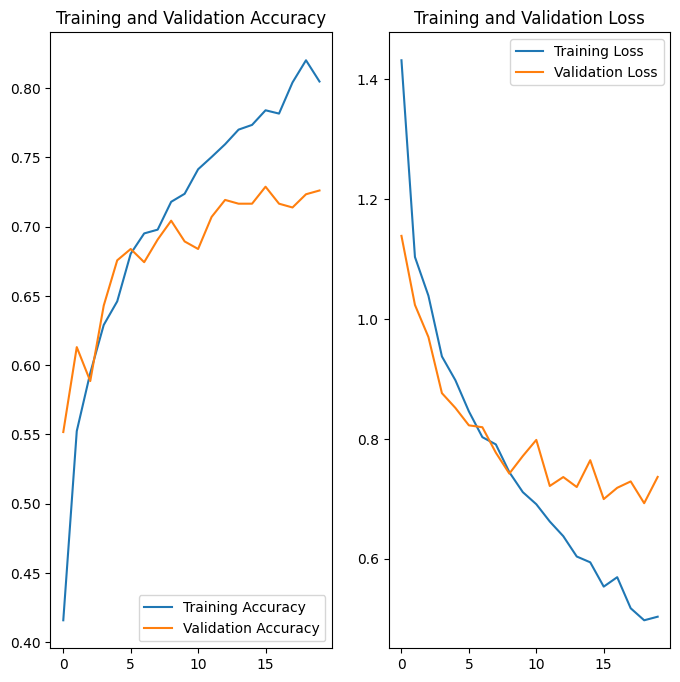

In [28]:

epochs = 20 # количество эпох
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=epochs)

# Визуализация
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

##Проверка работоспособности

1/1 [==============================] - 0s 481ms/step
На изображении скорее всего roses (98.13% вероятность)


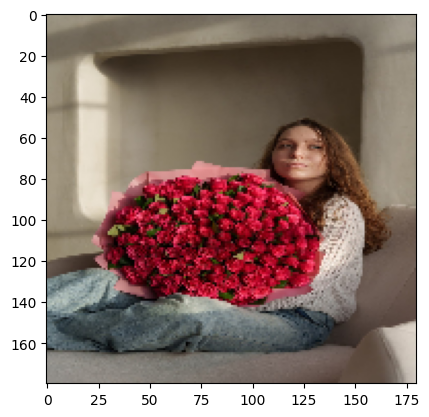

In [29]:
# Путь к изображению
sunflower_path = "/content/Test_photo.jpg"

# Загружаем изображение
img = tf.keras.utils.load_img(sunflower_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# Делаем предсказание
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# Выводим результат
class_name = class_names[np.argmax(score)]
confidence = 100 * np.max(score)
print(f"На изображении скорее всего {class_name} ({confidence:.2f}% вероятность)")

# Показываем изображение
plt.imshow(img)

##Экспорт файла модели (скачать себе на компьютер)

In [30]:
from google.colab import files

model_file_name = "flower_tester.h5"

# save model
model.save(model_file_name)

# download model
files.download(model_file_name)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>